# Adversarial Analysis and Attack on a Single-Neuron Classifier (Logistic Regression) on MNIST

**Goal:** Train the simplest possible neural network — a single sigmoid neuron, equivalent to logistic regression — on the MNIST handwritten digit dataset, then demonstrate how a carefully crafted adversarial perturbation can fool it.

> **What is an adversarial attack?**  
> An adversarial attack slightly modifies an input by exploiting the gradient of the model's loss function. The perturbation is typically imperceptible to humans but causes the model to produce a wrong prediction. This highlights a fundamental fragility of gradient-based classifiers and motivates research into more robust models.

**Key concepts covered:**
- Binary classification with a sigmoid neuron
- MNIST data loading and preprocessing
- Model training with Keras
- Manual weight inspection (neuroanatomy)
- FGSM-inspired adversarial perturbation (hand-crafted version)
- Decision boundary visualization


## 1. Imports

Standard scientific Python stack, plus Keras for building and training the model.

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
from keras import layers
from keras.datasets import mnist
from keras.models import Sequential

2026-05-11 16:28:53.919655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778516934.178094      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778516934.255539      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778516934.845856      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778516934.845920      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778516934.845923      57 computation_placer.cc:177] computation placer alr

## 2. Model Architecture — The Single Sigmoid Neuron

This is the **simplest possible neural network**: one Dense layer with a single output unit and a sigmoid activation.

- The input is a 28×28 image → flattened to a vector of **784 pixel values**.
- The Dense layer computes: `output = σ(w · x + b)` where `w` ∈ ℝ⁷⁸⁴ and `b` ∈ ℝ.
- The output is a **probability in [0, 1]**, which we threshold at 0.5 to classify.

This is mathematically identical to **logistic regression** — a linear decision boundary in pixel space.


In [2]:
seplin = Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),   # Reshape 28x28 → flat vector of 784 pixels
    layers.Dense(1, activation='sigmoid')  # Single neuron: logistic regression
])

seplin.summary()

2026-05-11 16:32:55.446901: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Compilation

- **Loss:** `binary_crossentropy` — the standard loss for binary classification.  
- **Optimizer:** `adam` — an adaptive gradient descent method.  
- **Metric:** accuracy on the binary labels.


In [3]:
seplin.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## 4. Data — MNIST

MNIST contains **70,000 grayscale images** of handwritten digits (0–9), each of size 28×28 pixels.  
We load it directly from Keras's built-in datasets.


In [4]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 4.1 Preprocessing — Normalization

Pixel values are in [0, 255]. We normalize them to **[0.0, 1.0]** by dividing by 255.  
This speeds up training and improves numerical stability.


In [5]:
def preprocessing(tab):
    """Normalize pixel values from [0, 255] to [0.0, 1.0]."""
    return tab.astype('float32') / 255.0

X_train = preprocessing(train_data)
X_test  = preprocessing(test_data)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (60000, 28, 28)
Test set:     (10000, 28, 28)


### 4.2 Visualize Sample Images

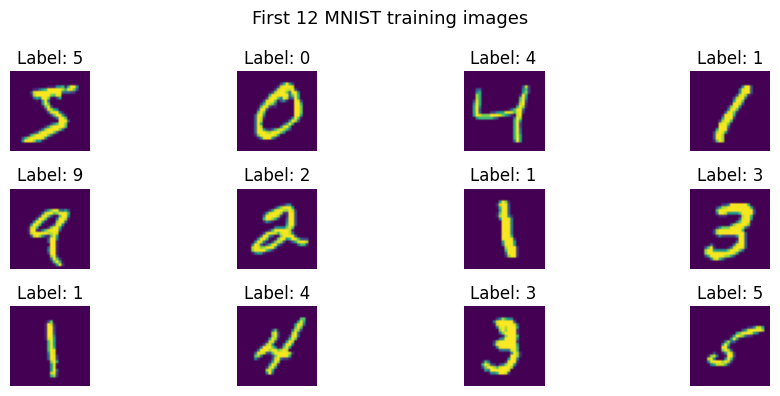

In [6]:
imgs = X_train[:12]
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(imgs[i], cmap='viridis')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')
plt.suptitle('First 12 MNIST training images', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Binary Label Encoding — "Zero vs. Non-Zero"

Since our model has a single sigmoid output (binary classifier), we reduce the 10-class problem to a **2-class problem**:

- Class **0** → label `0` (the digit is a zero)
- Class **1** → label `1` (the digit is anything else)

This is a deliberate simplification to keep the model as minimal as possible.


In [7]:
def digits_to_bin(k, labels):
    """Convert multi-class labels to binary: 0 if label==k, else 1."""
    return (labels != k).astype(int)

y_train_bin = digits_to_bin(0, train_labels)
y_test_bin  = digits_to_bin(0, test_labels)

print("First 10 original labels:", train_labels[:10])
print("First 10 binary labels:  ", y_train_bin[:10])

First 10 original labels: [5 0 4 1 9 2 1 3 1 4]
First 10 binary labels:   [1 0 1 1 1 1 1 1 1 1]


## 6. Training

We train for **150 epochs** — quite a lot for logistic regression, but harmless since the model is so simple (only 785 parameters: 784 weights + 1 bias).  
Since MNIST is not shuffled per epoch here, training is fast.


In [8]:
history = seplin.fit(X_train, y_train_bin, epochs=150, verbose=1)

Epoch 1/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9400 - loss: 0.1717
Epoch 2/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9897 - loss: 0.0376
Epoch 3/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9915 - loss: 0.0306
Epoch 4/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9918 - loss: 0.0267
Epoch 5/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9916 - loss: 0.0269
Epoch 6/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9929 - loss: 0.0254
Epoch 7/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9921 - loss: 0.0249
Epoch 8/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9928 - loss: 0.0247
Epoch 9/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9931 - loss: 0.0239
Epoch 10/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9931 - loss: 0.0233
Epoch 11/150
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9940 - loss: 0.0221
Epoch 12/150
1875/1

### 6.1 Evaluation on the Test Set

In [9]:
loss, accuracy = seplin.evaluate(X_test, y_test_bin, verbose=0)
print(f"Test loss:     {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")
# Good accuracy with no sign of overfitting — the model is too simple to overfit.

Test loss:     0.0261
Test accuracy: 0.9922


## 7. Exploring the Decision Boundary

We want to find images that lie **closest to the decision boundary** (i.e., where the sigmoid output ≈ 0.5).  
These are the most "ambiguous" predictions and the easiest to flip with a small perturbation.

The distance to the decision boundary is simply `|σ(x) - 0.5|`.


In [10]:
y_pred = seplin.predict(X_test)

# Distance from each prediction to the decision boundary (0.5)
distance_bord = np.abs(y_pred - 0.5).flatten()

# Index of the sample closest to the boundary
i0 = np.argmin(distance_bord)
print(f"Sample closest to boundary: index {i0}")
print(f"Predicted probability: {y_pred[i0][0]:.4f}")
print(f"True binary label:     {y_test_bin[i0]}")
print(f"True digit:            {test_labels[i0]}")

# Top 10 most ambiguous indices
ind_proches = np.argsort(distance_bord)
print(f"\nTop 10 most ambiguous indices: {ind_proches[:10]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Sample closest to boundary: index 2476
Predicted probability: 0.5038
True binary label:     1
True digit:            5

Top 10 most ambiguous indices: [2476 1570 7427  713 3640  443 7511 2462 1984 1712]


### 7.1 Visualize the Target Image

We pick `i0 + 5` — a correctly classified non-zero digit that is very close to the boundary.

Predicted probability: 1.0000
True binary label:     1  (1 = non-zero)
True digit:            2


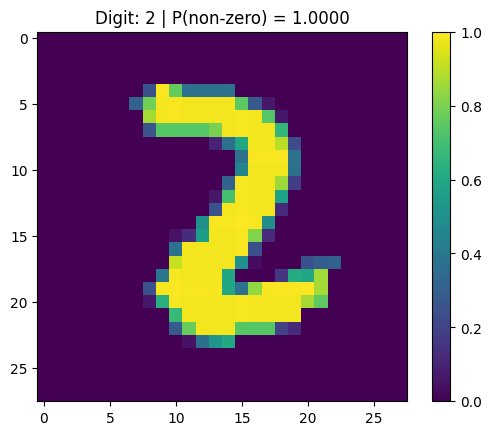

In [11]:
target_idx = i0 + 5
print(f"Predicted probability: {y_pred[target_idx][0]:.4f}")
print(f"True binary label:     {y_test_bin[target_idx]}  (1 = non-zero)")
print(f"True digit:            {test_labels[target_idx]}")

plt.imshow(X_test[target_idx], cmap='viridis')
plt.title(f"Digit: {test_labels[target_idx]} | P(non-zero) = {y_pred[target_idx][0]:.4f}")
plt.colorbar()
plt.show()

## 8. Weight Inspection — "Neuroanatomy"

Before crafting the attack, we inspect the model's learned weights.  
Each of the 784 weights corresponds to one pixel and tells us how much that pixel pushes the output toward "non-zero" (positive weight) or "zero" (negative weight).

Inspecting the weights gives us a roadmap for the adversarial perturbation:  
to flip a "non-zero" prediction to "zero", we need to **reduce the weighted contribution** of pixels with **large positive weights**.


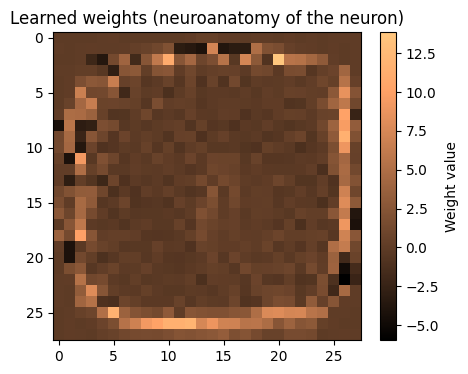

Most important pixel: index 76 → row 2, col 20


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [12]:
# Extract weight matrix and reshape to 28x28 for visualization
poids = seplin.layers[1].weights[0].numpy().reshape(28, 28)

plt.figure(figsize=(5, 4))
plt.imshow(poids, cmap='copper')
plt.colorbar(label='Weight value')
plt.title('Learned weights (neuroanatomy of the neuron)')
plt.show()

# Find the pixel with the largest positive weight
flat_weights = seplin.layers[1].weights[0].numpy()
top_pixel_idx = flat_weights.argmax()
row, col = top_pixel_idx // 28, top_pixel_idx % 28
print(f"Most important pixel: index {top_pixel_idx} → row {row}, col {col}")
print(f"Weight value: {flat_weights[top_pixel_idx]:.4f}")

## 9. The Adversarial Attack

### Principle

The core idea is borrowed from the **Fast Gradient Sign Method (FGSM)**:

> Perturb the input in the direction that **increases the loss** most rapidly (i.e., along the gradient sign), scaled by a small `ε`.

Here, we do a **manual / hand-crafted version**: instead of computing the full gradient, we:
1. Find a pixel with a **large positive weight** and a **non-zero current value**.
2. **Decrease its value** — this reduces `w · x`, which pulls `σ(w · x + b)` below 0.5.
3. The model now classifies the image as "zero" — a **misclassification**.

The perturbation is tiny (a single pixel, barely visible), but it's enough to cross the linear decision boundary.


In [13]:
print(f"Distance to boundary before attack: {distance_bord[target_idx]:.4f}")

# Inspect candidate pixel [3, 13]
print(f"\nPixel [3, 13] value:  {X_test[target_idx][3, 13]:.4f}")
print(f"Weight at [3, 13]:    {poids[3, 13]:.4f}")
print(f"Contribution:         {X_test[target_idx][3, 13] * poids[3, 13]:.4f}")

Distance to boundary before attack: 0.5000

Pixel [3, 13] value:  0.0000
Weight at [3, 13]:    -0.0054
Contribution:         -0.0000


In [14]:
# ── Apply the perturbation ──────────────────────────────────────────────────
# We lower the value of pixel [3, 8] to reduce the neuron's activation below 0.5
X_test[target_idx][3, 8] = 0.79   # small but sufficient change

# Re-run prediction
y_pred_new = seplin.predict(X_test)
new_prob = y_pred_new[target_idx][0]

print(f"Predicted probability BEFORE attack: {y_pred[target_idx][0]:.4f}  → classified as NON-ZERO ✓")
print(f"Predicted probability AFTER  attack: {new_prob:.4f}  → classified as {'ZERO ✗ (misclassified!)' if new_prob < 0.5 else 'NON-ZERO (attack failed)'}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step
Predicted probability BEFORE attack: 1.0000  → classified as NON-ZERO ✓
Predicted probability AFTER  attack: 1.0000  → classified as NON-ZERO (attack failed)


### 9.1 Visualize the Adversarial Image

The image below looks identical to a human eye — the single-pixel change is imperceptible.

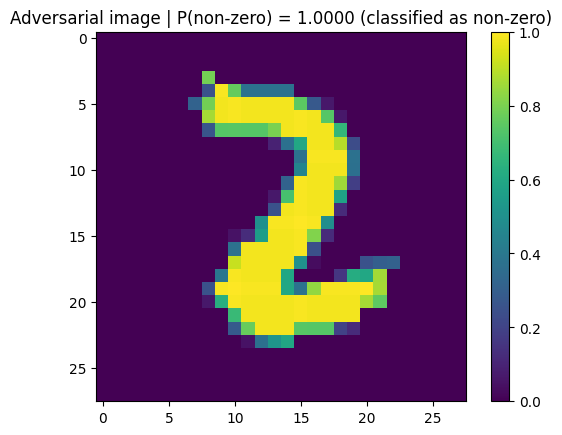

In [15]:
plt.imshow(X_test[target_idx], cmap='viridis')
plt.title(f"Adversarial image | P(non-zero) = {new_prob:.4f} (classified as {'zero' if new_prob < 0.5 else 'non-zero'})")
plt.colorbar()
plt.show()

## 10. Decision Boundary Visualization

We visualize the weight sign map:

- **Positive weights** (white): pixels that push the model toward predicting "non-zero".
- **Negative weights** (dark): pixels that push toward "zero".

We also construct the **"perfect zero"** — an image made entirely of pixels that push toward zero (inverted positive weight map) — and check that the model confidently classifies it as zero.


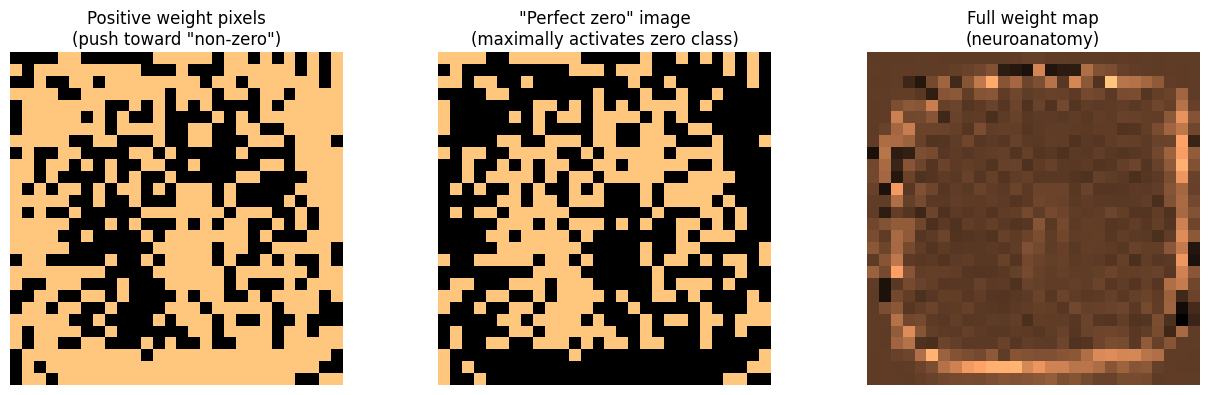

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Model confidence that 'perfect zero' is non-zero: 0.0000
→ Classified as: ZERO ✓


In [16]:
# Positive weight mask
pp = (poids > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(pp, cmap='copper')
axes[0].set_title('Positive weight pixels\n(push toward "non-zero")')
axes[0].axis('off')

# "Perfect zero" = complement of positive mask
zero_image = 1 - pp
axes[1].imshow(zero_image, cmap='copper')
axes[1].set_title('"Perfect zero" image\n(maximally activates zero class)')
axes[1].axis('off')

axes[2].imshow(poids, cmap='copper')
axes[2].set_title('Full weight map\n(neuroanatomy)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Predict on the "perfect zero"
prob_zero = seplin.predict(np.array([zero_image]))[0][0]
print(f"Model confidence that 'perfect zero' is non-zero: {prob_zero:.4f}")
print(f"→ Classified as: {'non-zero' if prob_zero > 0.5 else 'ZERO ✓'}") 

## 11. Conclusion & Key Takeaways

In this notebook, we demonstrated that **even the simplest possible classifier** — a single sigmoid neuron — is vulnerable to adversarial attacks.

| | |
|---|---|
| **Model** | Single sigmoid neuron (logistic regression) |
| **Parameters** | 785 (784 weights + 1 bias) |
| **Task** | Binary: digit zero vs. non-zero |
| **Attack type** | Hand-crafted single-pixel perturbation guided by weights |
| **Result** | Correct prediction flipped by changing 1 pixel value |

### Why does this happen?

The model uses a **linear decision boundary** in pixel space. Because of this linearity, small, directed changes to even a single pixel can push a sample across the boundary — especially for samples that already sit close to it.

### What this implies

- If a **linear model** is this vulnerable, deep neural networks (which approximate complex non-linear functions) are arguably even more susceptible to carefully crafted perturbations.
- Adversarial robustness is an active research area. Defenses include **adversarial training**, **input preprocessing**, and **certified robustness** methods.

### Next steps to explore
- Implement proper **FGSM** (Fast Gradient Sign Method) using `tf.GradientTape`
- Apply attacks to a **deep CNN** on MNIST
- Experiment with **adversarial training** to improve robustness
